In [1]:
import requests
import pandas as pd
import time
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns

# Creating Climate Impact Matrix

In [2]:
# Load data
stock_df = pd.read_excel('Stock_Data(Clean).xlsx')
df1 = pd.read_csv('nyt_climate_news_updated.csv')

# Convert and format dates
stock_df['Dates'] = pd.to_datetime(stock_df['Dates'])
df1['pub_date'] = pd.to_datetime(df1['pub_date'])
news_dates = df1['pub_date'].dt.normalize()

# Initialize empty list for CIM entries
cim_list = []

# Loop through companies in pairs of open and close
for i in range(1, len(stock_df.columns), 2):
    open_col = stock_df.columns[i]
    close_col = stock_df.columns[i+1]
    company = open_col.split(' ')[0]  # Extract ticker
    
    temp_df = pd.DataFrame()
    temp_df['Dates'] = stock_df['Dates']
    temp_df['Open'] = stock_df[open_col]
    temp_df['Close'] = stock_df[close_col]
    temp_df['Company'] = company

    # Filter to news dates
    temp_df = temp_df[temp_df['Dates'].isin(news_dates)].copy()
    
    # Calculate return
    temp_df['Returns'] = (temp_df['Close'] - temp_df['Open']) / temp_df['Open']

    # Append to list
    cim_list.append(temp_df)

# Combine all company data into one CIM
CIM = pd.concat(cim_list).reset_index(drop=True)

# Compute mean and std for standardizing (per company)
CIM['Standardized Returns'] = CIM.groupby('Company')['Returns'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Flag jump days (using 1 std threshold)
CIM['Jump Indicator (Y/N)'] = CIM['Standardized Returns'].apply(lambda z: 'Y' if abs(z) > 1 else 'N')

# Final CIM preview
CIM.head(15)


,Dates,Open,Close,Company,Returns,Standardized Returns,Jump Indicator (Y/N)
0,2014-11-11,92.28,91.74,AXP,-0.005852,-0.588353,N
1,2014-11-12,91.19,91.55,AXP,0.003948,0.225928,N
2,2014-11-13,91.70,91.07,AXP,-0.006870,-0.672981,N
3,2014-11-28,91.61,92.42,AXP,0.008842,0.632591,N
4,2015-04-20,77.45,77.23,AXP,-0.002841,-0.338140,N
5,2015-06-30,78.17,77.72,AXP,-0.005757,-0.580453,N
6,2015-11-03,74.15,74.03,AXP,-0.001618,-0.236583,N
7,2015-11-06,74.37,74.30,AXP,-0.000941,-0.180320,N
8,2015-11-12,72.72,71.98,AXP,-0.010176,-0.947671,N
9,2015-11-30,71.85,71.64,AXP,-0.002923,-0.344971,N


# Creating Jump Impact Matrix

In [3]:
# Step 1: Filter CIM to include only rows where Jump Indicator is 'Y'
JIM = CIM[CIM['Jump Indicator (Y/N)'] == 'Y'].copy()

# Step 2: Drop 'Jump Returns' and 'Jump Indicator (Y/N)' columns
JIM = JIM.drop(columns=['Standardized Returns', 'Jump Indicator (Y/N)'])

# Step 3: Reset index for clarity
JIM = JIM.reset_index(drop=True)

# Display JIM
JIM.head(50)

,Dates,Open,Close,Company,Returns
0,2016-09-13,65.23,64.36,AXP,-0.013337
1,2017-11-07,96.42,95.37,AXP,-0.010890
2,2018-12-04,111.95,107.64,AXP,-0.038499
3,2019-08-13,123.32,126.32,AXP,0.024327
4,2019-10-23,118.42,116.49,AXP,-0.016298
5,2020-04-01,80.65,77.84,AXP,-0.034842
6,2020-05-13,82.00,78.03,AXP,-0.048415
7,2020-11-04,94.12,96.40,AXP,0.024224
8,2021-02-19,129.55,131.71,AXP,0.016673
9,2021-09-23,169.40,173.36,AXP,0.023377


# Estimating Jump Intensity(i.e. lambda)

In [4]:
lambda_dict = {}

# Ensure datetime and sorting
CIM['Dates'] = pd.to_datetime(CIM['Dates'])
JIM['Dates'] = pd.to_datetime(JIM['Dates'])

# Loop over each company
for company in JIM['Company'].unique():
    company_CIM = CIM[CIM['Company'] == company].sort_values('Dates').reset_index(drop=True)
    company_JIM = JIM[JIM['Company'] == company].sort_values('Dates').reset_index(drop=True)
    
    if len(company_JIM) < 2:
        lambda_dict[company] = None  # Not enough jumps to calculate λ
        continue

    t_0 = company_CIM['Dates'].iloc[0]
    time_intervals = company_JIM['Dates'].diff().dt.days.dropna()
    initial_interval = (company_JIM['Dates'].iloc[0] - t_0).days
    time_intervals = pd.concat([pd.Series([initial_interval]), time_intervals], ignore_index=True)

    m = len(time_intervals) - 1
    if m == 0:
        lambda_dict[company] = None
    else:
        avg_interval = time_intervals.sum() / m
        lambda_dict[company] = 1 / avg_interval

# Convert results to DataFrame
lambda_df = pd.DataFrame(list(lambda_dict.items()), columns=['Company', 'Lambda'])

# Display
lambda_df.head()


,Company,Lambda
0,AXP,0.005186
1,VZ,0.007889
2,AVGO,0.005713
3,BA,0.005459
4,CAT,0.007642


# Estimating Average Jump Size k

In [5]:
k_dict = {}

# Loop over each company in JIM
for company in JIM['Company'].unique():
    company_JIM = JIM[JIM['Company'] == company]
    
    m = len(company_JIM)
    if m == 0:
        k_dict[company] = None  # No jump days, cannot compute k
    else:
        k_dict[company] = company_JIM['Returns'].sum() / m

# Convert results to DataFrame
k_df = pd.DataFrame(list(k_dict.items()), columns=['Company', 'k'])

# Display
k_df.head()

,Company,k
0,AXP,0.002032
1,VZ,0.001838
2,AVGO,0.001451
3,BA,0.000615
4,CAT,-0.002029


# $\theta$ Scores Across Companies

In [6]:
# Merge lambda and k
theta_df = pd.merge(lambda_df, k_df, on='Company')

# Compute θ = λ * k
theta_df['Theta'] = theta_df['Lambda'] * theta_df['k']

# Drop rows with None or NaN values
theta_df = theta_df.dropna()

# Display
theta_df.head()


,Company,Lambda,k,Theta
0,AXP,0.005186,0.002032,0.000011
1,VZ,0.007889,0.001838,0.000015
2,AVGO,0.005713,0.001451,0.000008
3,BA,0.005459,0.000615,0.000003
4,CAT,0.007642,-0.002029,-0.000016


# Normalizing ESG Scores

In [7]:
# Normalize Theta values to ESG scores on a 0–100 scale
theta_min = theta_df['Theta'].min()
theta_max = theta_df['Theta'].max()

theta_df['ESG_Score'] = 100 * (theta_df['Theta'] - theta_min) / (theta_max - theta_min)

# Save to Excel
theta_df.to_excel('theta_output.xlsx', index=False)

# Display ESG scores
theta_df[['Company', 'Theta', 'ESG_Score']].sort_values('ESG_Score', ascending=False)

,Company,Theta,ESG_Score
71,NVDA,0.000050,100.000000
87,KKR,0.000035,87.143878
40,MU,0.000034,86.030788
49,UNP,0.000032,84.017718
84,META,0.000032,83.850892
...,...,...,...
31,DHR,-0.000024,34.182312
34,NEE,-0.000025,32.639874
32,DE,-0.000031,27.619054
76,NFLX,-0.000033,25.546380


# Histogram of ESG Scores

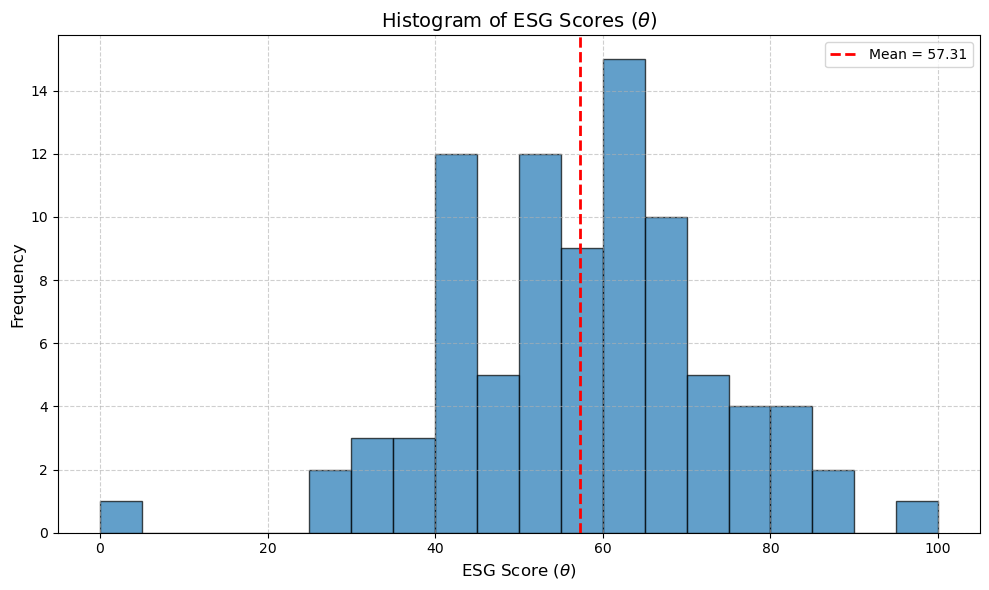

In [8]:
# Calculate mean ESG score
mean_score = theta_df['ESG_Score'].mean()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(theta_df['ESG_Score'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_score:.2f}')
plt.title(r'Histogram of ESG Scores ($\theta$)', fontsize=14)
plt.xlabel(r'ESG Score ($\theta$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig("histogram of ESG Scores.png", dpi=300)

# Show the plot
plt.show()


# Top 10 and Bottom 10 ESG Scores

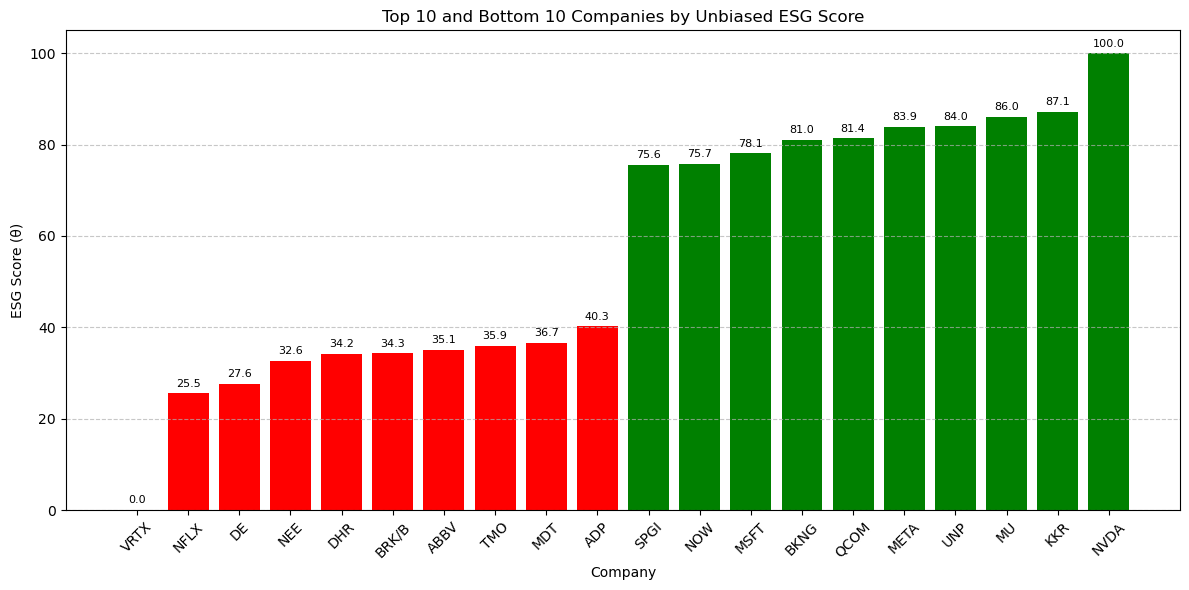

In [9]:
# Get top and bottom 10 ESG scores
top_10 = theta_df.sort_values(by='ESG_Score', ascending=False).head(10)
bottom_10 = theta_df.sort_values(by='ESG_Score', ascending=True).head(10)

# Combine and label them
combined = pd.concat([top_10, bottom_10])
combined['Rank'] = ['Top'] * 10 + ['Bottom'] * 10

# Sort for visual clarity (e.g., from lowest to highest)
combined = combined.sort_values(by='ESG_Score')

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(combined['Company'], combined['ESG_Score'], color=['green' if r == 'Top' else 'red' for r in combined['Rank']])

# Formatting
plt.xlabel('Company')
plt.ylabel('ESG Score (θ)')
plt.title('Top 10 and Bottom 10 Companies by Unbiased ESG Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Optional: add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}', ha='center', va='bottom', fontsize=8)


# Save the figure
plt.savefig('top_bottom_10_ESG_scores.png', dpi=300, bbox_inches='tight')

# Show
plt.show()


# Histogram jump vs. non-jump days

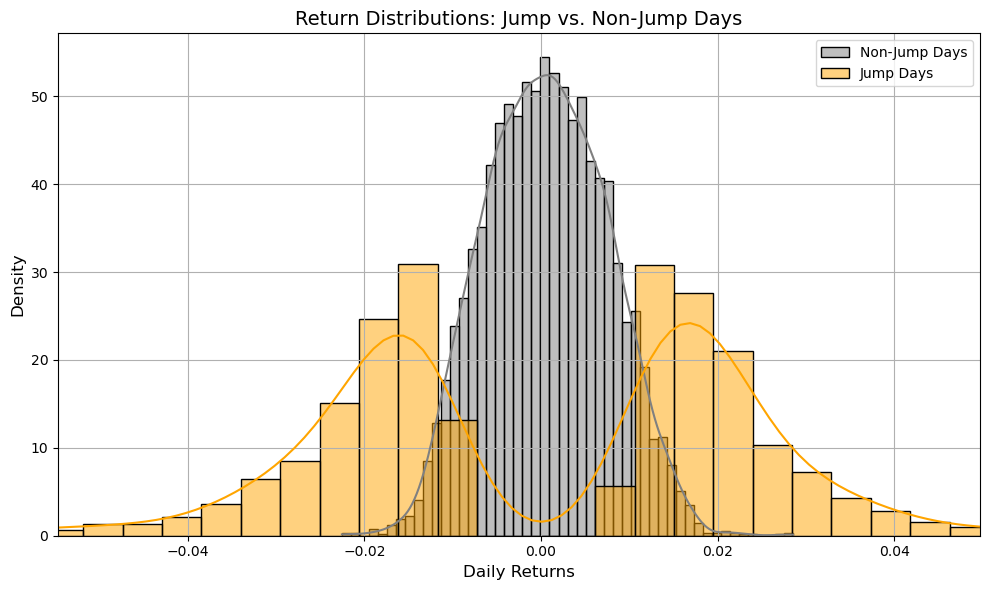

In [10]:
# Extract returns
jump_returns = CIM[CIM['Jump Indicator (Y/N)'] == 'Y']['Returns']
non_jump_returns = CIM[CIM['Jump Indicator (Y/N)'] == 'N']['Returns']

# Calculate 1st and 99th percentiles for x-axis limits to remove outliers
min_val = min(jump_returns.quantile(0.01), non_jump_returns.quantile(0.01))
max_val = max(jump_returns.quantile(0.99), non_jump_returns.quantile(0.99))

# Plot overlapping histograms
plt.figure(figsize=(10, 6))
sns.histplot(non_jump_returns, bins=50, color='gray', label='Non-Jump Days', kde=True, stat='density')
sns.histplot(jump_returns, bins=50, color='orange', label='Jump Days', kde=True, stat='density')

plt.xlim(min_val, max_val)
plt.xlabel('Daily Returns', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Return Distributions: Jump vs. Non-Jump Days', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("return_distributions_jump_vs_nonjump.png")
plt.show()


# Climate News Volume Over Time(quarterly)

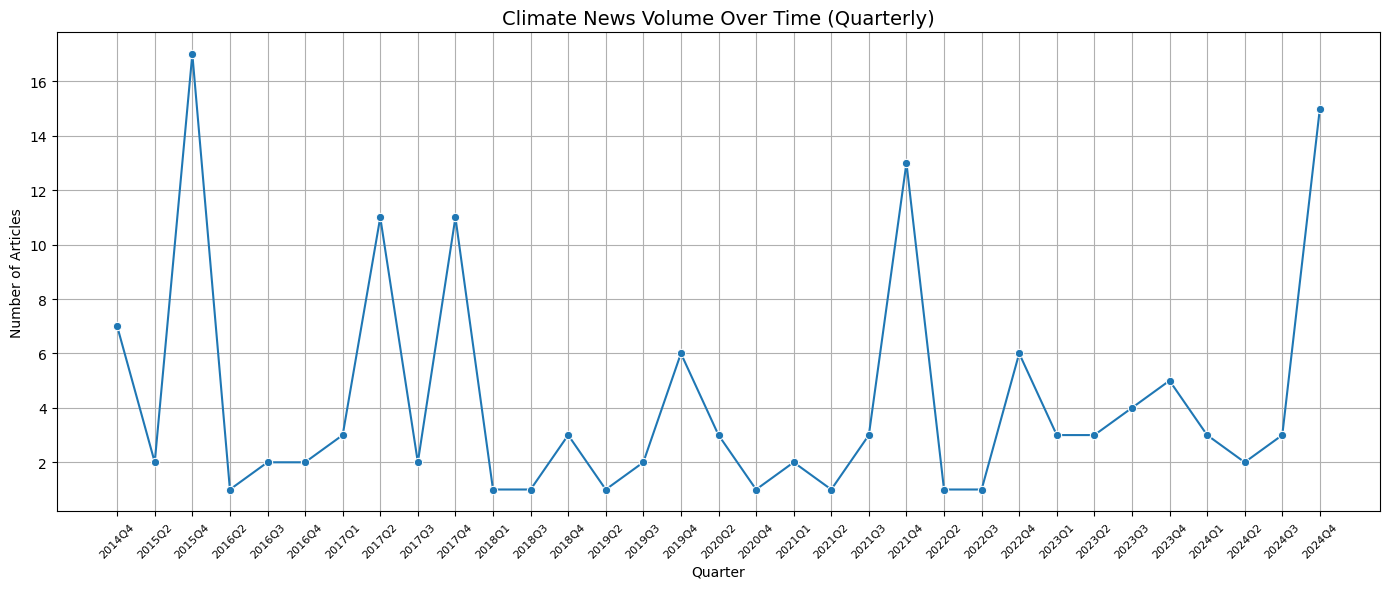

In [11]:
# Group by quarter and count articles
df1['Quarter'] = df1['pub_date'].dt.to_period('Q').astype(str)
quarterly_counts = df1.groupby('Quarter').size().reset_index(name='Article Count')

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_counts, x='Quarter', y='Article Count', marker='o')
plt.xticks(rotation=45, fontsize=8)
plt.title('Climate News Volume Over Time (Quarterly)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.grid(True)

# Optional: Save the figure
plt.savefig("climate_news_volume_quarterly.png", dpi=300)

plt.show()

# Case Study - Jump Events(XOM)

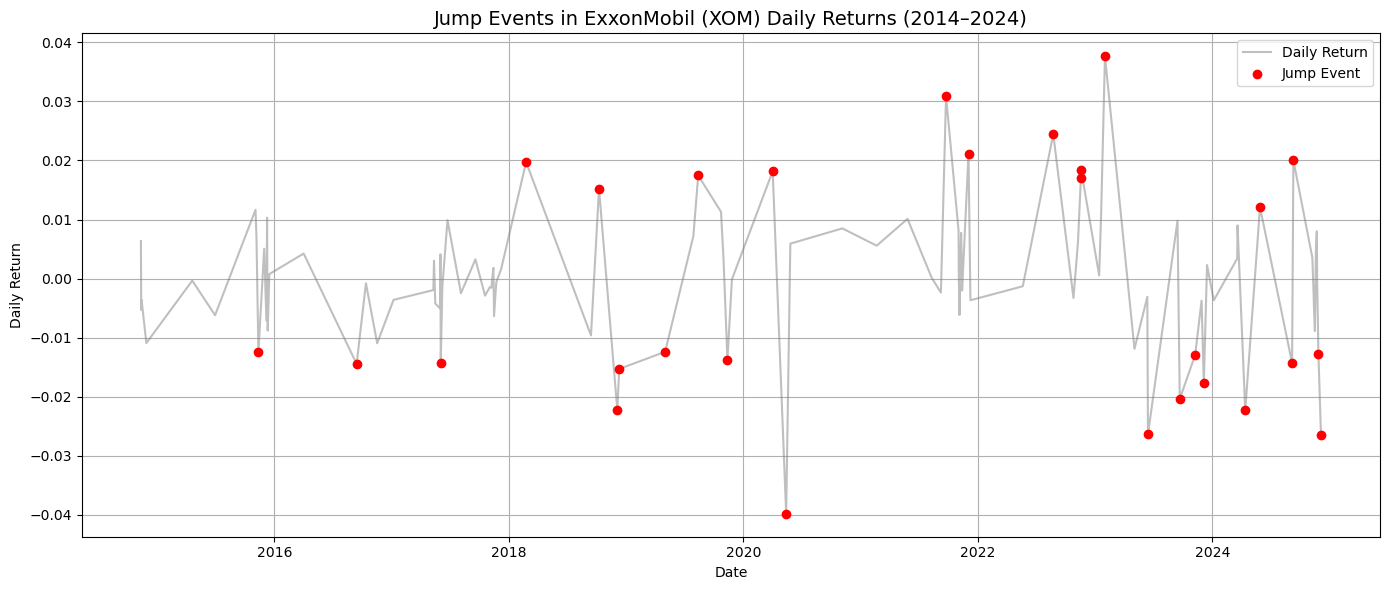

In [12]:
# Sort by date
CIM_XOM = CIM[CIM['Company'] == 'XOM'].sort_values('Dates')

# Split jump and non-jump data
jump_data = CIM_XOM[CIM_XOM['Jump Indicator (Y/N)'] == 'Y']
non_jump_data = CIM_XOM[CIM_XOM['Jump Indicator (Y/N)'] == 'N']

# Plot
plt.figure(figsize=(14, 6))
plt.plot(CIM_XOM['Dates'], CIM_XOM['Returns'], color='gray', label='Daily Return', alpha=0.5)
plt.scatter(jump_data['Dates'], jump_data['Returns'], color='red', label='Jump Event', zorder=5)

plt.title('Jump Events in ExxonMobil (XOM) Daily Returns (2014–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("XOM_Jump_Events_Cleaned.png", dpi=300)
plt.show()

In [13]:
xom_df = CIM[CIM['Company'] == 'XOM'].copy()

# --- Step 1: Ensure Dates column is datetime ---
xom_df['Dates'] = pd.to_datetime(xom_df['Dates'])

# --- Step 2: Extract jump days ---
jump_days = xom_df.loc[xom_df['Jump Indicator (Y/N)'] == 'Y', 'Dates'].sort_values().reset_index(drop=True)

# --- Step 3: Define t0 (first date in CIM, regardless of jump) ---
t0 = xom_df['Dates'].min()

# --- Step 4: Construct list of [t0, t1, t2, ..., tm] ---
all_jump_times = pd.concat([pd.Series([t0]), jump_days]).reset_index(drop=True)

# --- Step 5: Compute differences between consecutive jump days (in trading days) ---
# Using calendar days, not trading gaps
intervals = all_jump_times.diff().dropna().dt.days  

# --- Step 6: Apply formula for lambda ---
lambda_xom = 1 / intervals.mean()

print(f"λ (Poisson jump intensity) for XOM: {lambda_xom:.6f}")

λ (Poisson jump intensity) for XOM: 0.007617


In [14]:
from scipy.stats import percentileofscore

# Extract XOM's ESG Score
xom_esg = theta_df.loc[theta_df['Company'] == 'XOM', 'ESG_Score'].values[0]

# Compute XOM's percentile rank
xom_percentile = percentileofscore(theta_df['ESG_Score'], xom_esg, kind='rank')

# Output
print(f"XOM ESG Score: {xom_esg:.2f}")
print(f"XOM ESG Percentile: {xom_percentile:.2f}th percentile")


XOM ESG Score: 44.49
XOM ESG Percentile: 22.73th percentile
